In [21]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

dataset = pd.read_csv('Data/Ads_CTR_Optimisation.csv')

In [22]:
N = 10000          # total rounds
d = 10             # number of ads

ads_selected = []
numbers_of_selections = [0] * d
sums_of_rewards = [0] * d
total_reward = 0

In [23]:
for n in range(1, N):
    
    ad = 0
    max_ucb = 0
    
    for i in range(d):

        if numbers_of_selections[i] > 0:
            average_reward = sums_of_rewards[i] / numbers_of_selections[i]
            delta = math.sqrt((3/2) * math.log(n) / numbers_of_selections[i])
            ucb = average_reward + delta

        else:
            ucb = float('inf')   # force trying each ad once

        if ucb > max_ucb:
            max_ucb = ucb
            ad = i

    ads_selected.append(ad)
    numbers_of_selections[ad] += 1
    reward = dataset.values[n, ad]   # click or no click
    sums_of_rewards[ad] += reward
    total_reward += reward

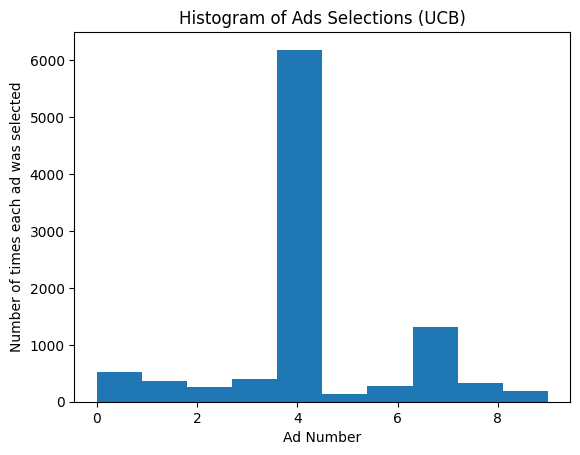

In [24]:
plt.hist(ads_selected)
plt.title("Histogram of Ads Selections (UCB)")
plt.xlabel("Ad Number")
plt.ylabel("Number of times each ad was selected")
plt.show()